# Paper Figures
Generate publication-quality figures for the research paper.

In [1]:
import sys
sys.path.insert(0, '..')

import json
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.evaluation.visualizations import *

# Publication-quality settings
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

FIGURES_DIR = '../docs/paper/figures/'
os.makedirs(FIGURES_DIR, exist_ok=True)

In [2]:
# Load results
results_dir = '../experiments/results/'
result_files = sorted(glob.glob(os.path.join(results_dir, 'experiment_*.json')))

if result_files:
    with open(result_files[-1]) as f:
        data = json.load(f)
    print(f'Loaded results from {data["timestamp"]}')
else:
    print('No results found. Run experiments first.')

Loaded results from 20260404_153425


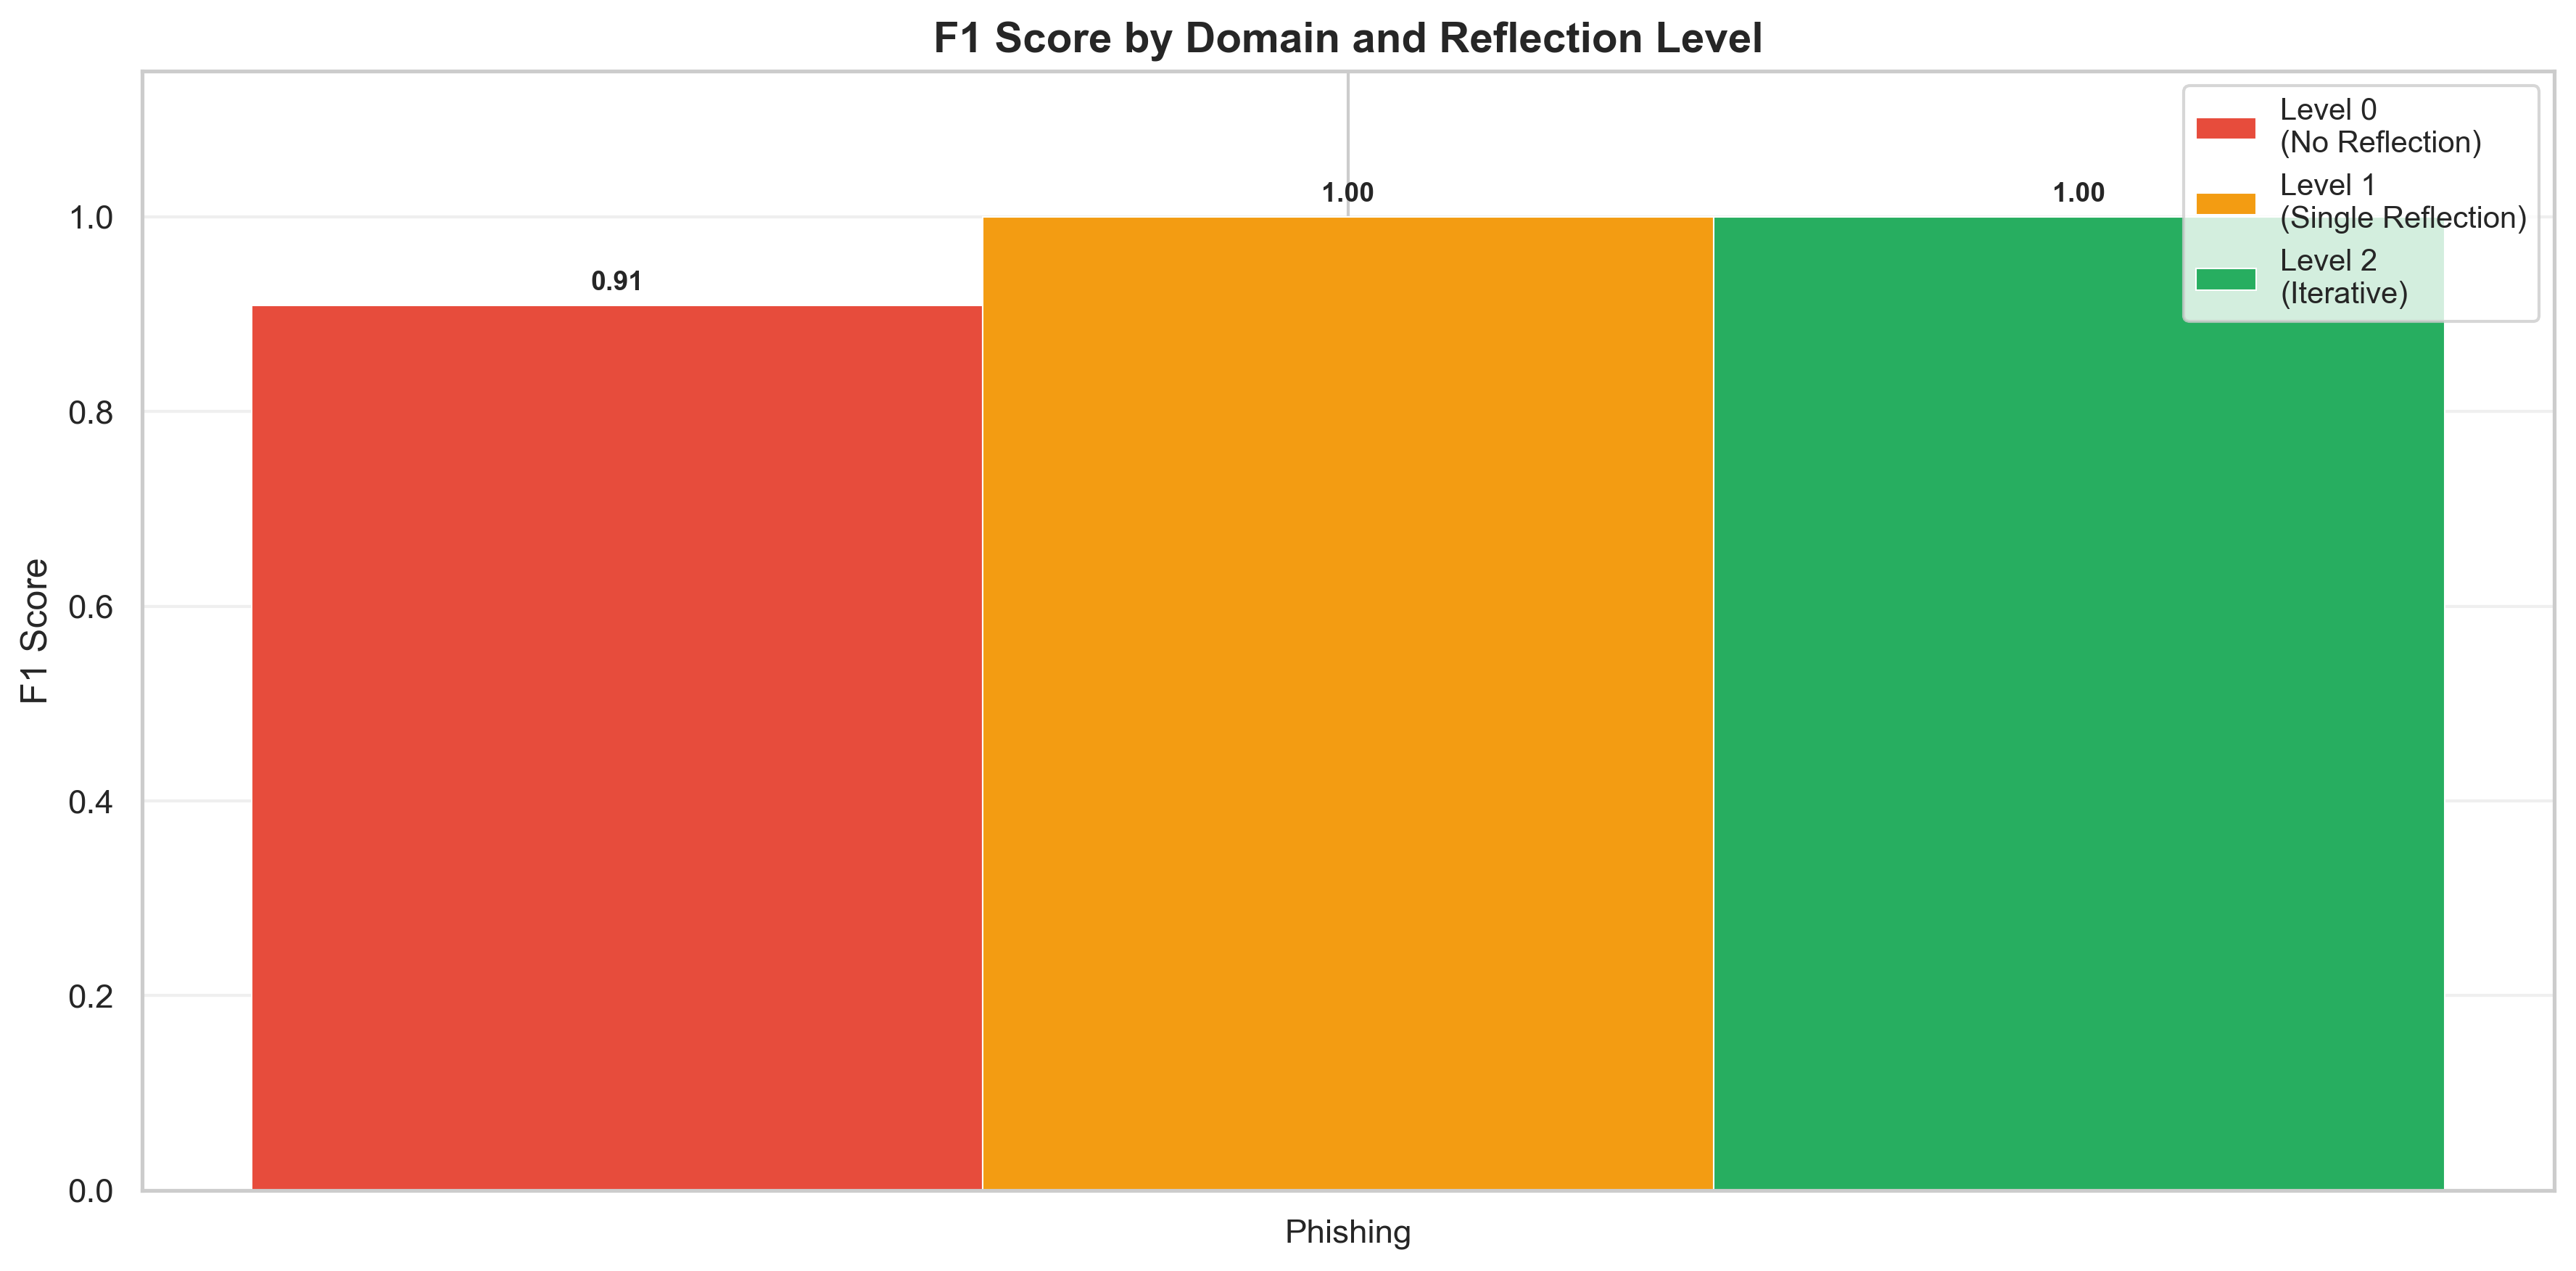

Saved: fig1_domain_comparison.png


In [3]:
# Figure 1: Overall performance comparison across domains
if result_files:
    domain_metrics = {}
    for domain in data['results']:
        domain_metrics[domain] = {}
        for level_str, result in data['results'][domain].items():
            domain_metrics[domain][int(level_str)] = result['metrics']
    
    fig = plot_domain_comparison(domain_metrics,
        save_path=os.path.join(FIGURES_DIR, 'fig1_domain_comparison.png'))
    plt.show()
    print('Saved: fig1_domain_comparison.png')

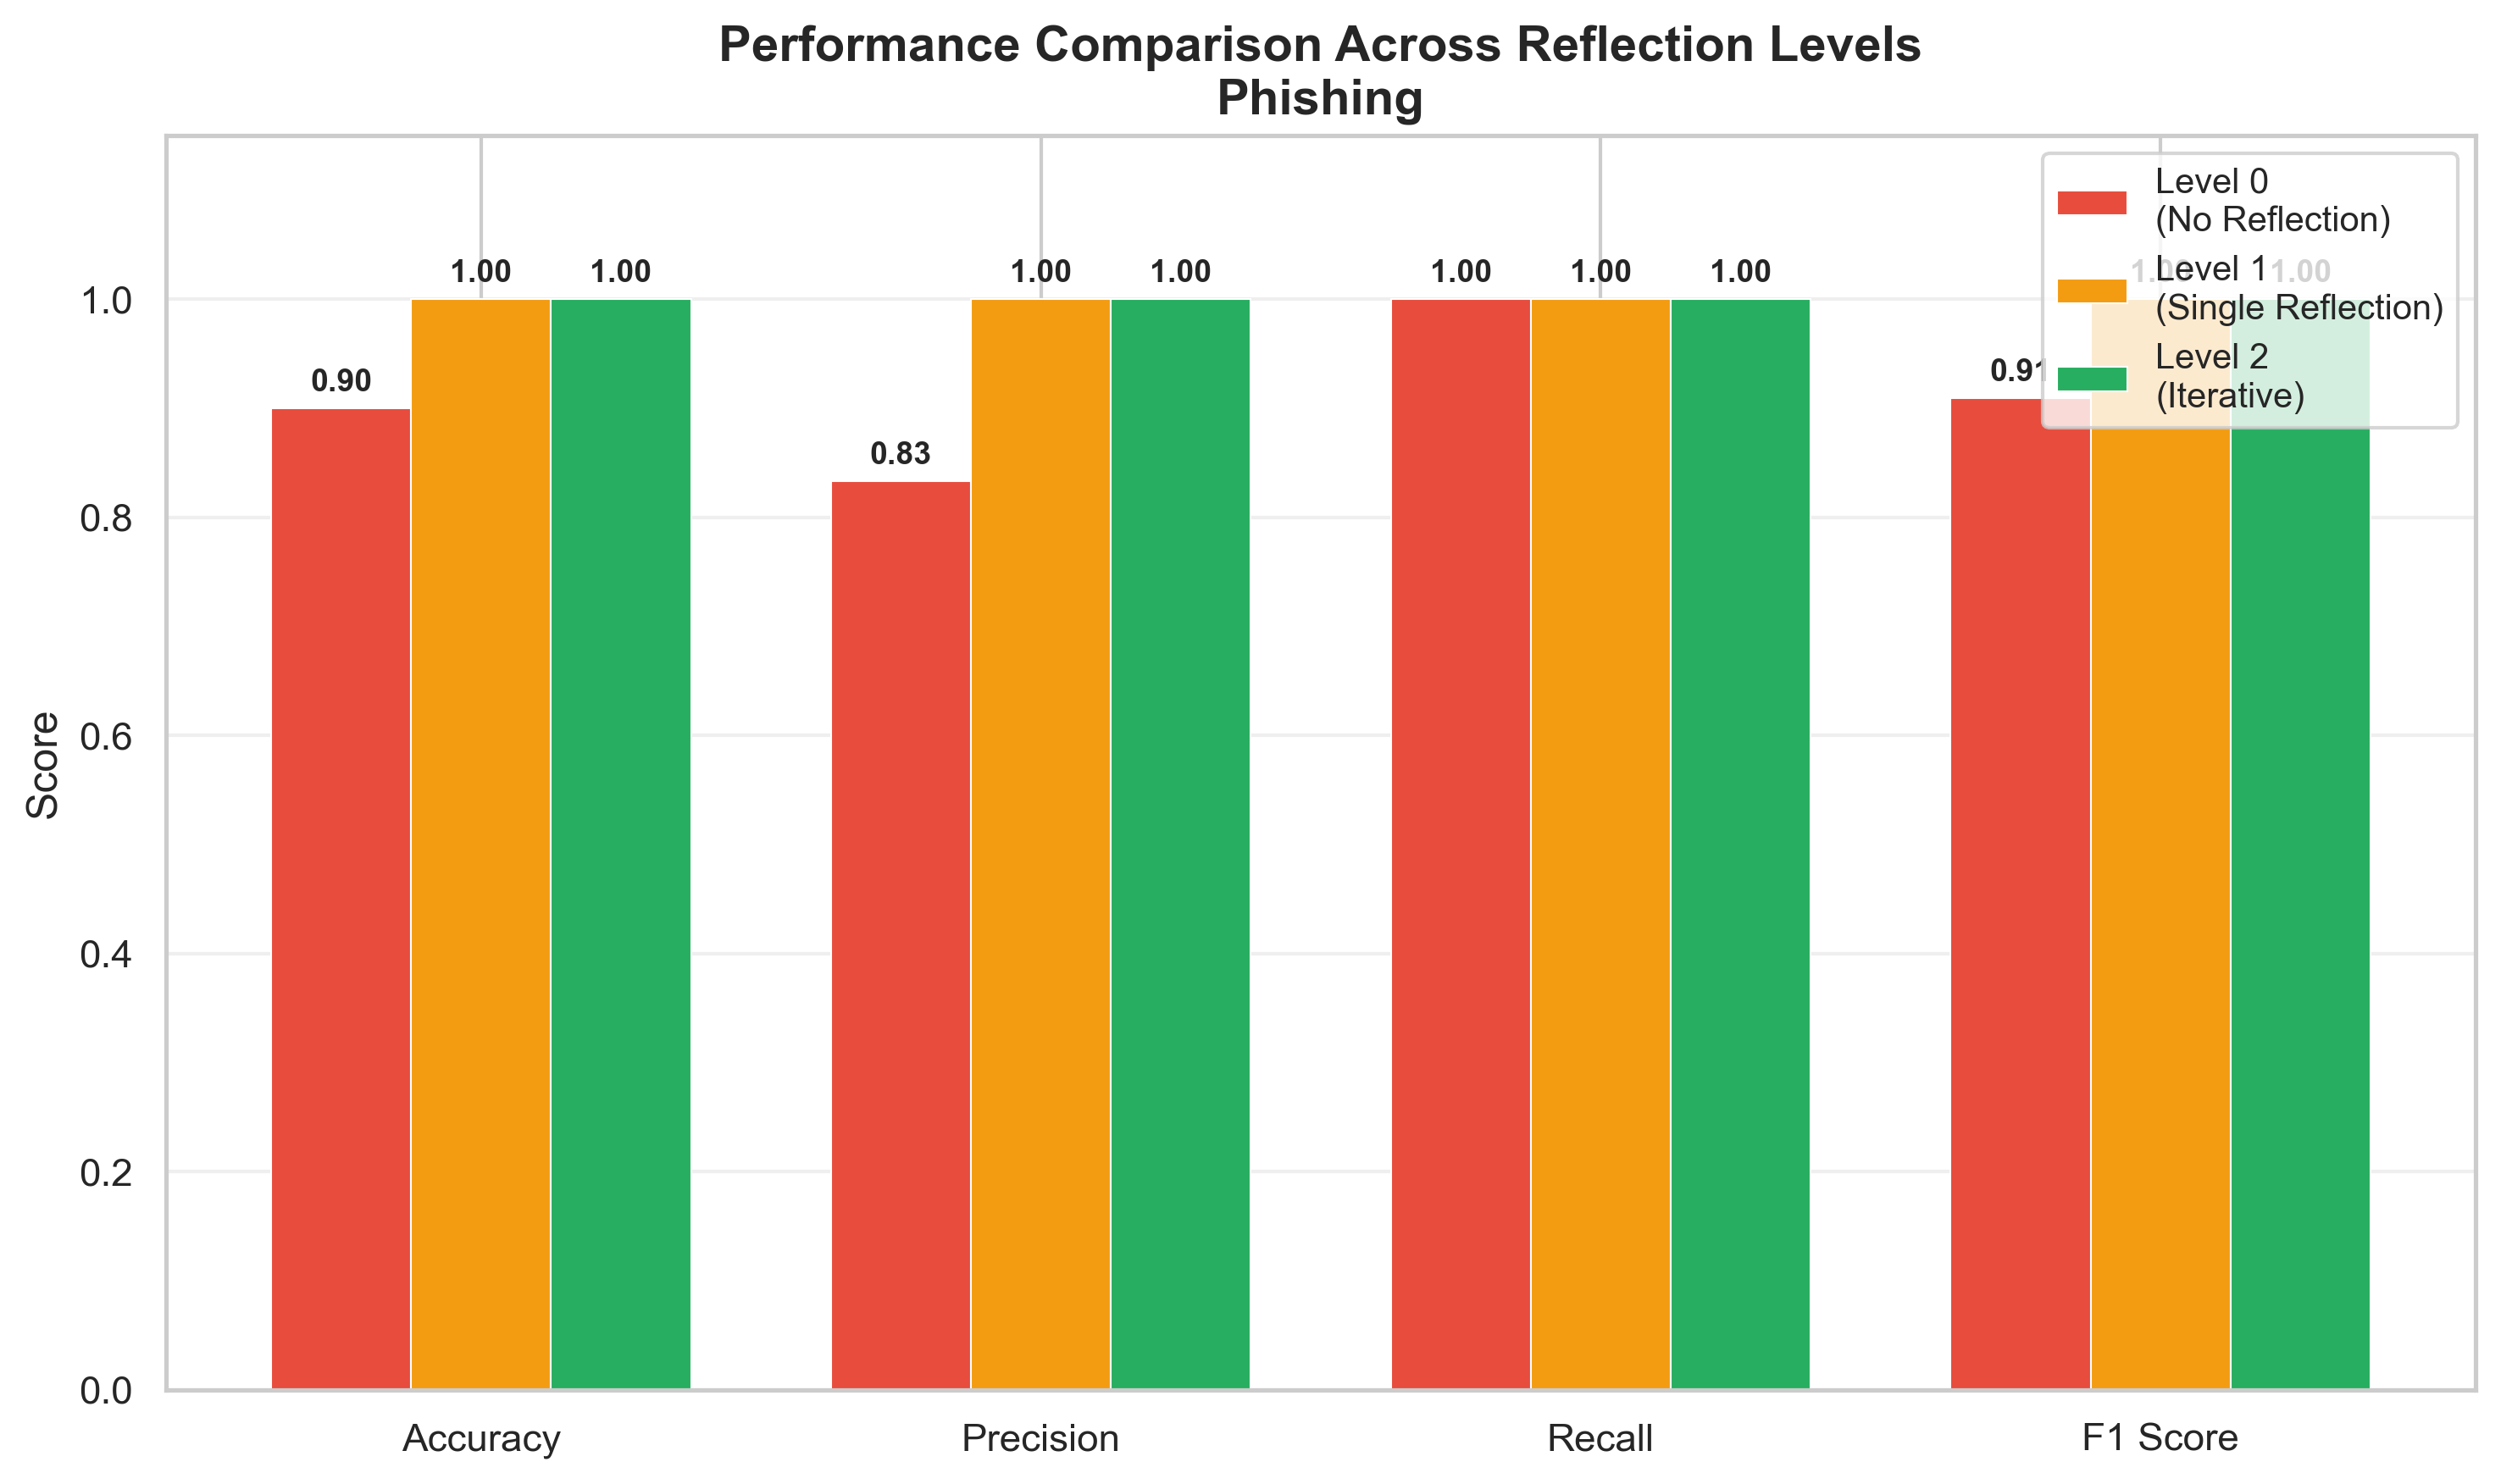

In [4]:
# Figure 2: Per-domain performance comparison
if result_files:
    for domain in data['results']:
        metrics_by_level = {}
        for level_str, result in data['results'][domain].items():
            metrics_by_level[int(level_str)] = result['metrics']
        
        fig = plot_comparison(metrics_by_level,
            domain=domain.replace('_', ' ').title(),
            save_path=os.path.join(FIGURES_DIR, f'fig2_{domain}_comparison.png'))
        plt.show()

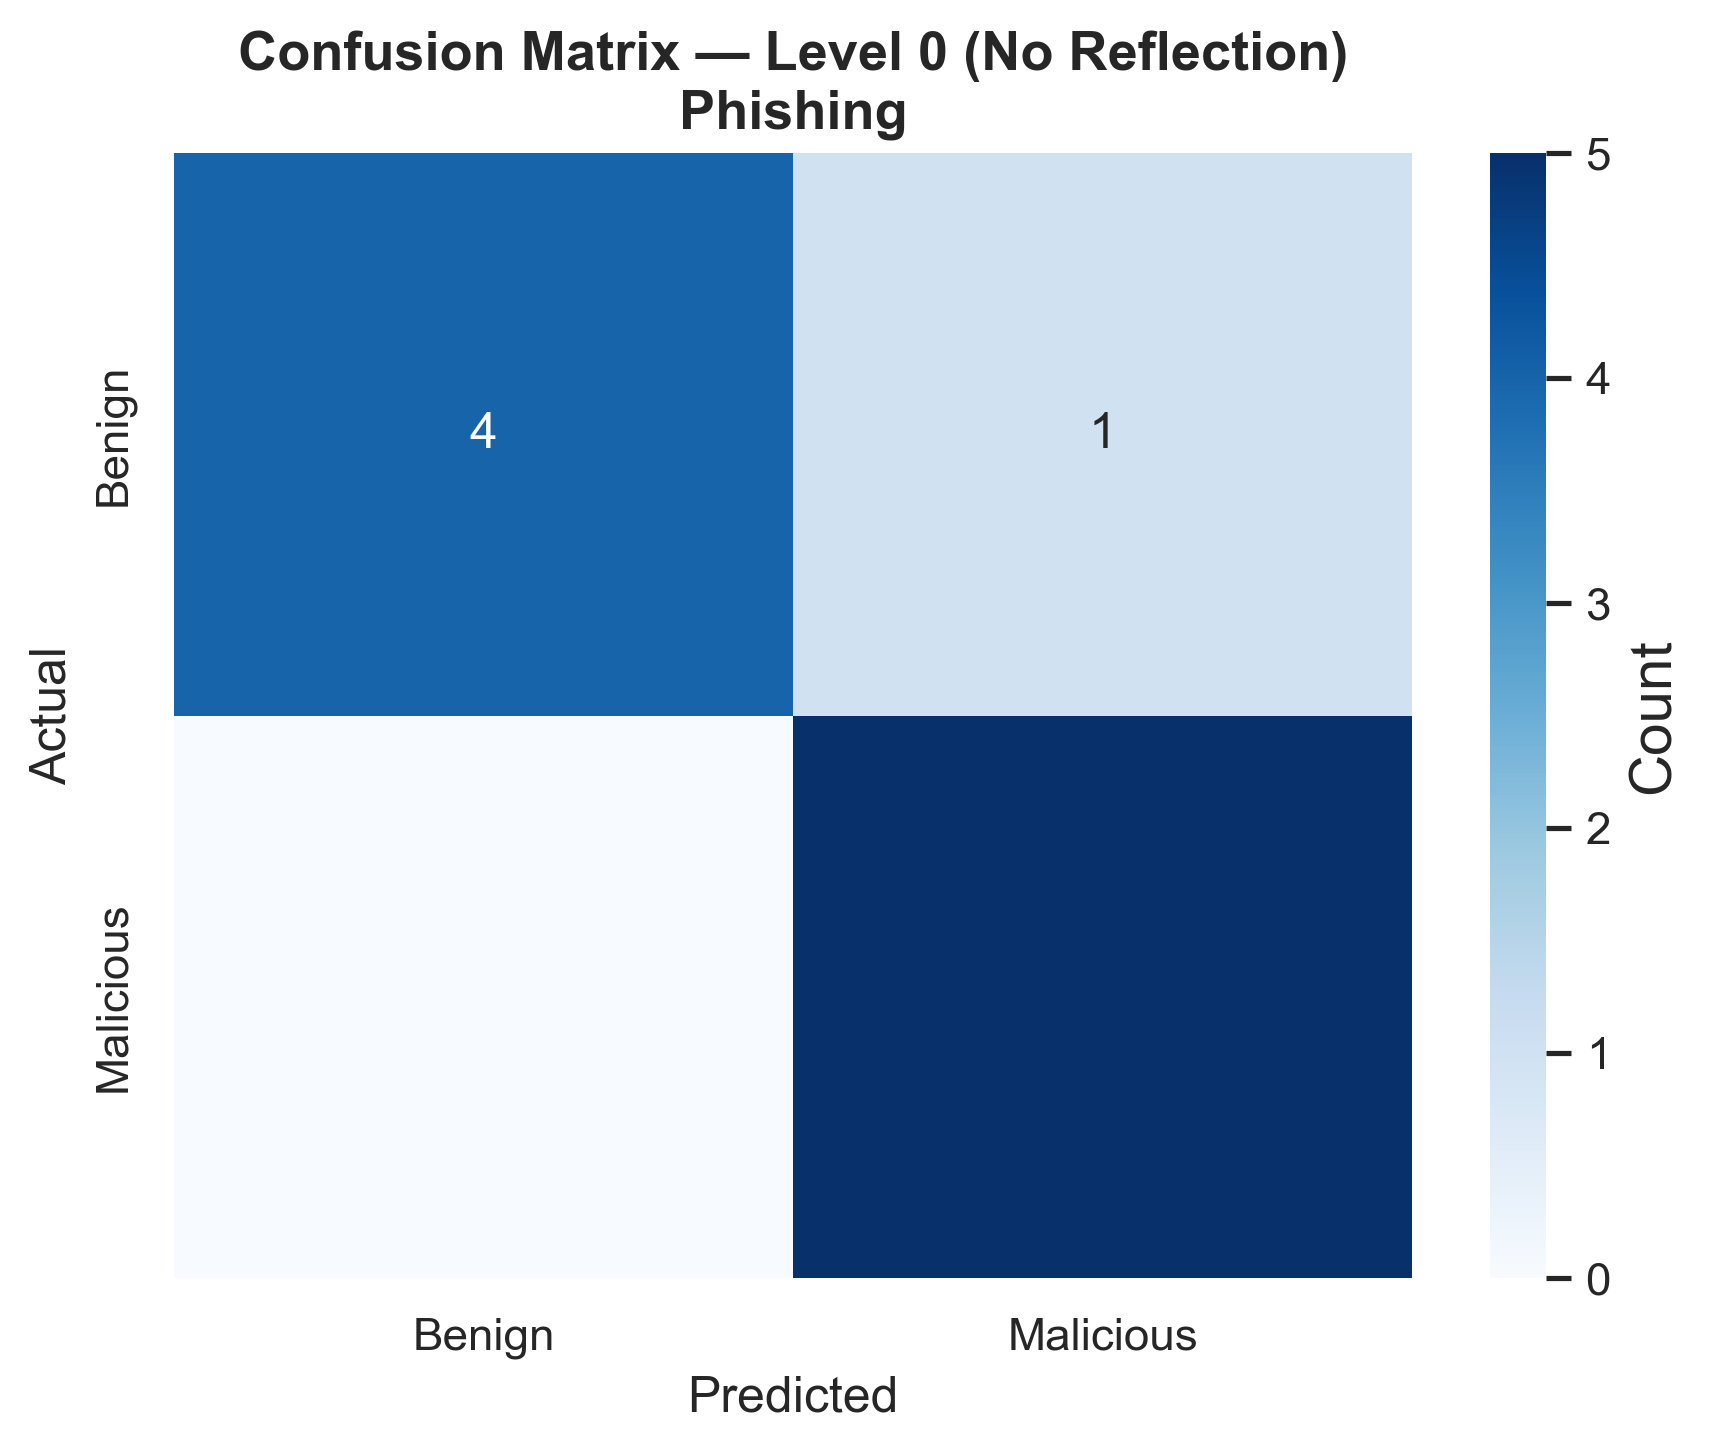

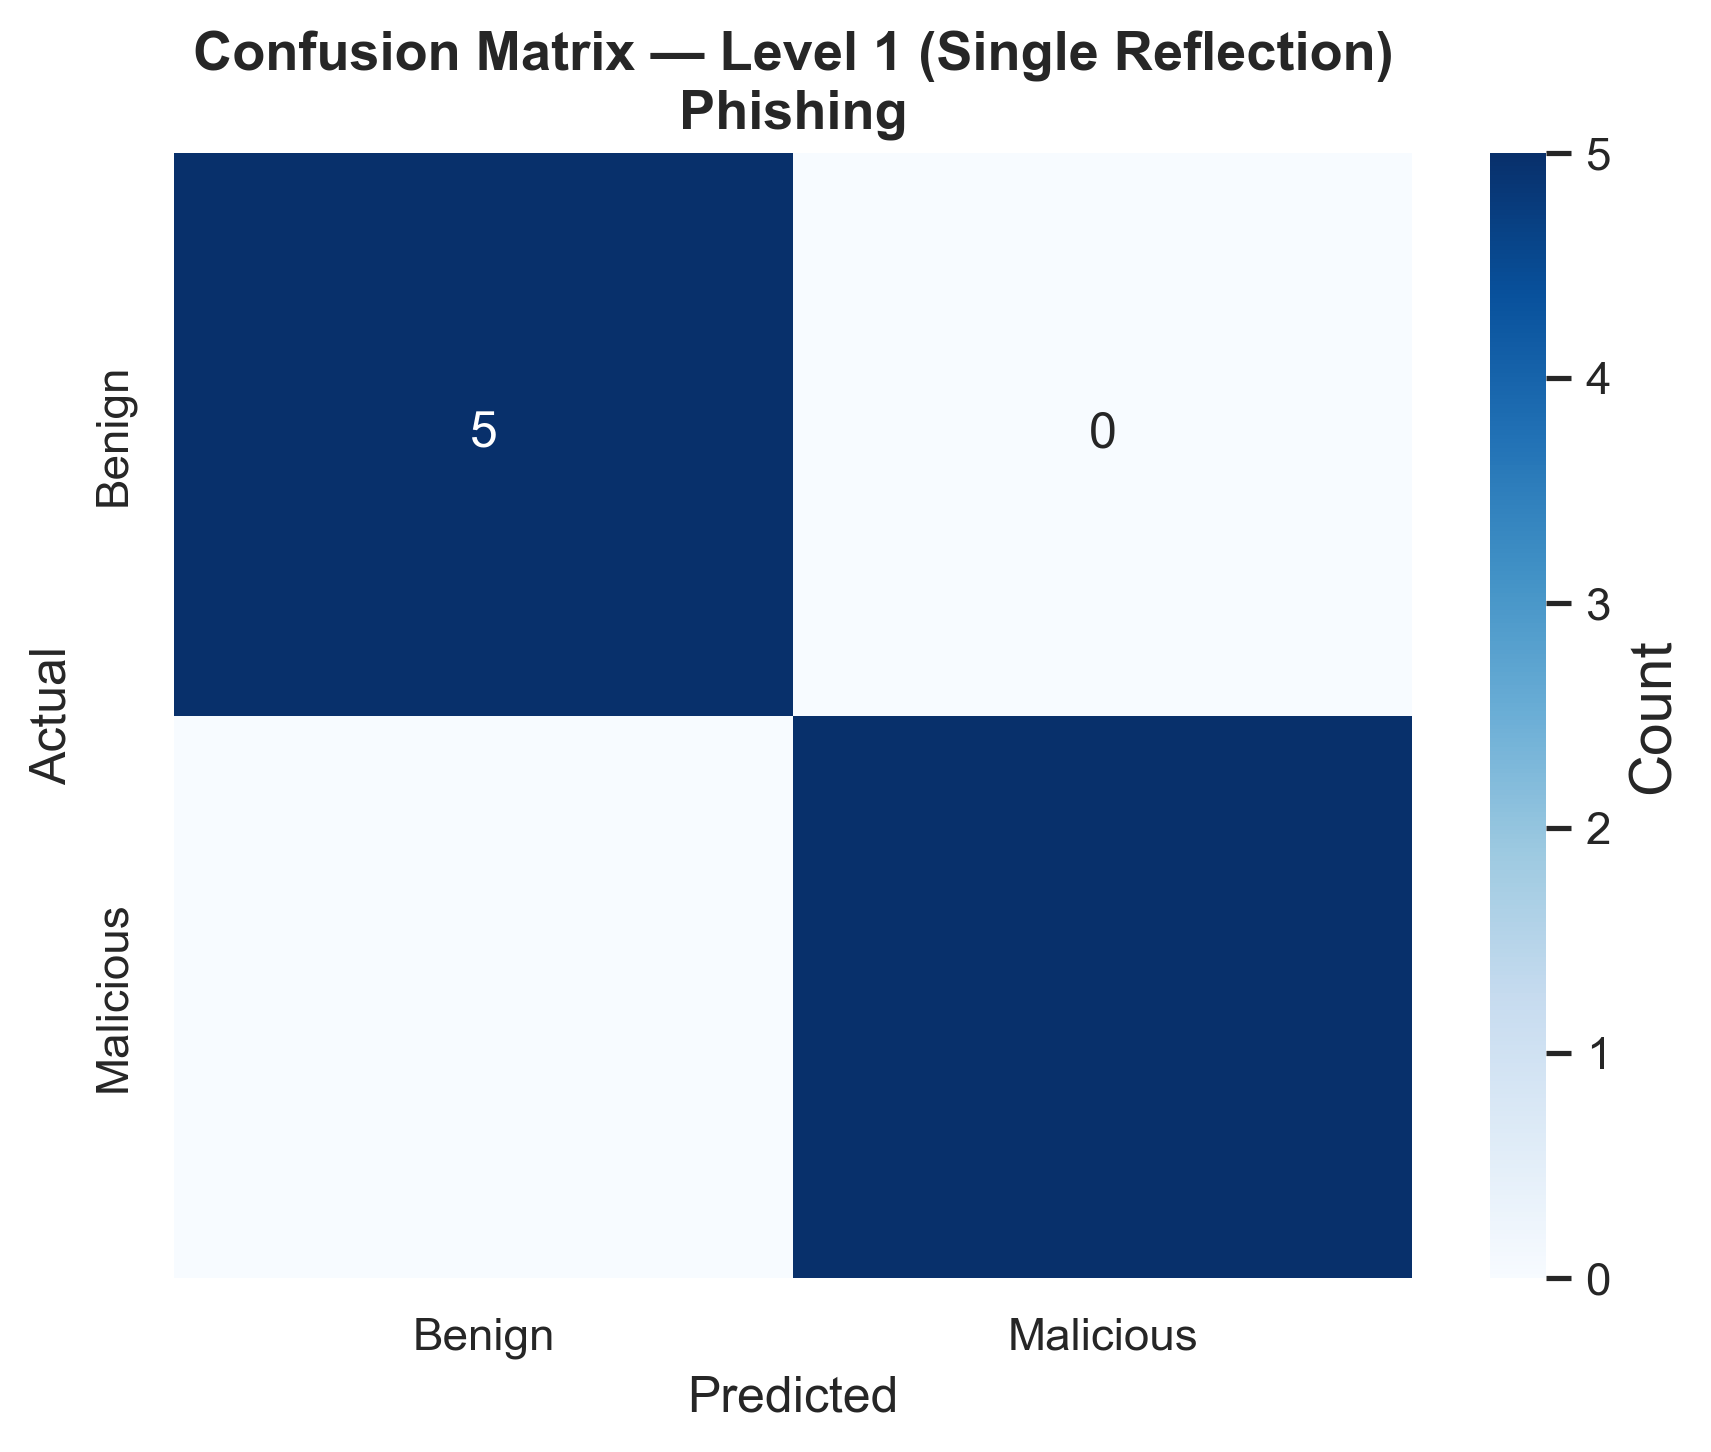

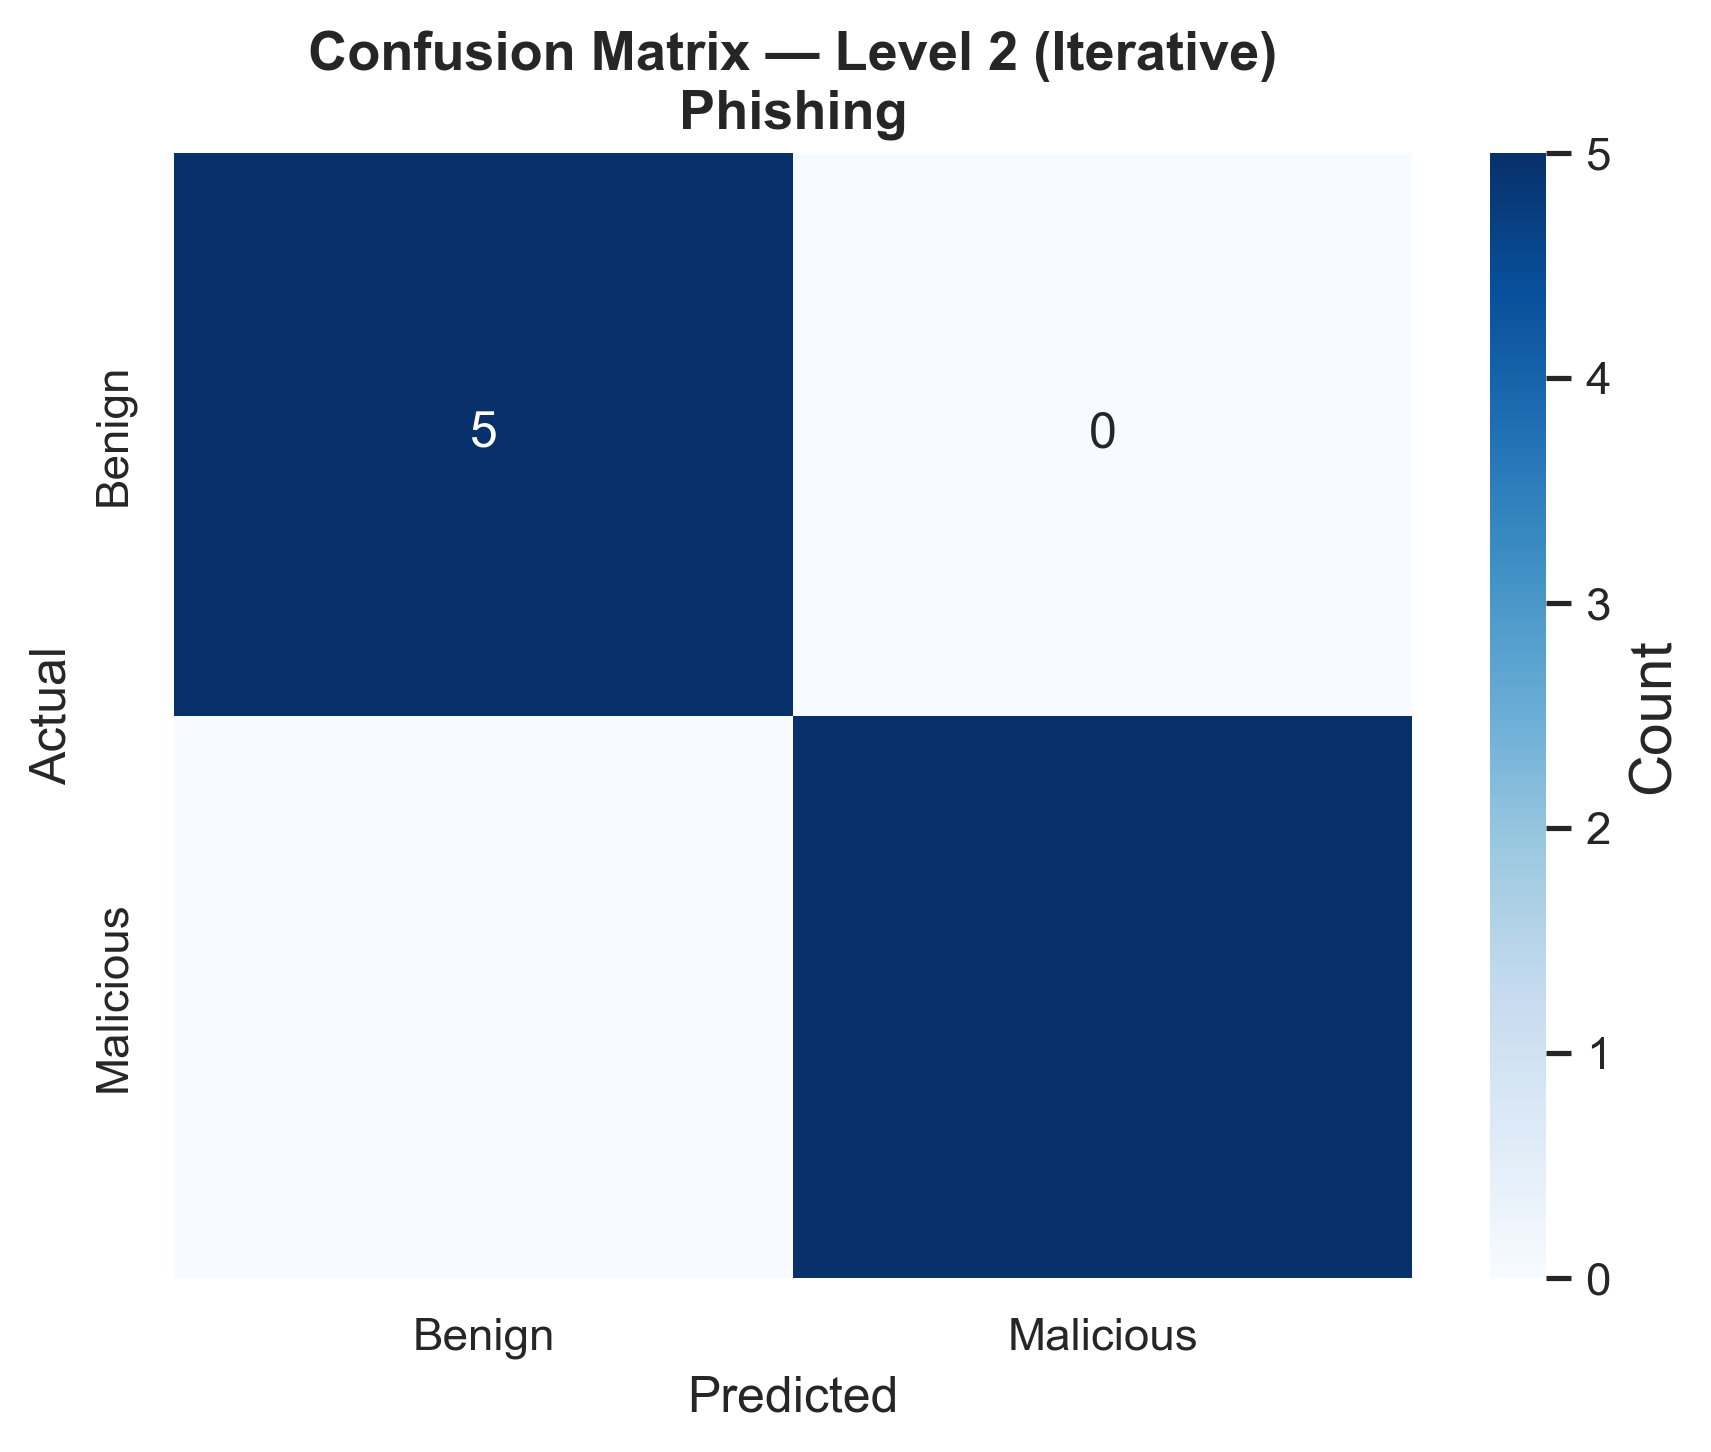

In [5]:
# Figure 3: Confusion matrices
if result_files:
    for domain in data['results']:
        for level_str, result in data['results'][domain].items():
            level = int(level_str)
            preds = result['predictions']
            y_true = [p['true_label'] for p in preds]
            y_pred = [p['predicted'] for p in preds]
            
            fig = plot_confusion_matrix(y_true, y_pred, level=level,
                domain=domain.replace('_', ' ').title(),
                save_path=os.path.join(FIGURES_DIR, f'fig3_cm_{domain}_level{level}.png'))
            plt.show()

In [6]:
# Figure 4: Summary table for paper
if result_files:
    rows = []
    for domain in data['results']:
        for level_str, result in data['results'][domain].items():
            m = result['metrics']
            rows.append({
                'Domain': domain.replace('_', ' ').title(),
                'Level': int(level_str),
                'Accuracy': f"{m['accuracy']:.3f}",
                'Precision': f"{m['precision']:.3f}",
                'Recall': f"{m['recall']:.3f}",
                'F1': f"{m['f1_score']:.3f}",
                'FPR': f"{m['false_positive_rate']:.3f}",
                'FNR': f"{m['false_negative_rate']:.3f}",
            })
    
    summary_df = pd.DataFrame(rows)
    print(summary_df.to_string(index=False))
    summary_df.to_csv(os.path.join(FIGURES_DIR, 'results_table.csv'), index=False)
    print('\nSaved: results_table.csv')

  Domain  Level Accuracy Precision Recall    F1   FPR   FNR
Phishing      0    0.900     0.833  1.000 0.909 0.200 0.000
Phishing      1    1.000     1.000  1.000 1.000 0.000 0.000
Phishing      2    1.000     1.000  1.000 1.000 0.000 0.000

Saved: results_table.csv
